# 機器學習入門：用 Logistic Regression 預測顧客是否購買

適合第一次接觸**分類預測**的學習者；只需基本 Python 與 pandas 操作。

## 學習目標

- 分辨特徵 `X` 與答案 `y`。
- 理解分類模型如何從機率得到 0／1。
- 建立、評估 Logistic Regression，並預測新資料。
- 看懂混淆矩陣、precision 與 recall。


## 學習流程

1. 定義問題與答案
2. 準備資料
3. 分割訓練集與測試集
4. 訓練模型
5. 解讀機率與分類結果
6. 評估、預測與練習


## 1. 我們要預測什麼？

商業問題是：**顧客進入網站後，這次工作階段是否會購買？**

- `target = 1`：有購買
- `target = 0`：沒有購買

答案只有兩類，因此是二元分類。Logistic Regression 名稱雖有 Regression，主要用途卻是分類：先估計購買機率，再透過門檻轉為 0 或 1。


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from common import build_features, load_data

RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)


## 2. 載入模型資料

一列代表一次工作階段。這次只選四個容易理解的特徵：瀏覽頁數、加入購物車次數、進站小時、是否為週末。

> 不可把 `purchase` 當特徵，因為它就是答案，會造成答案洩漏。


In [2]:
data = load_data()
model_df = build_features(data)
feature_names = ["page_view", "add_to_cart", "session_hour", "is_weekend"]
model_df = model_df[feature_names + ["target"]].dropna().copy()
print(f"模型資料共有 {len(model_df):,} 筆工作階段")
display(model_df.head())


模型資料共有 70,000 筆工作階段


,page_view,add_to_cart,session_hour,is_weekend,target
0,2,0,11,0,0
1,5,1,11,0,0
2,3,0,16,0,0
3,2,0,16,0,0
4,3,0,8,1,0


### 特徵 X 與答案 y

`X` 是提供給模型的線索，`y` 是希望模型學會預測的正確答案。先檢查兩類的比例；若購買者很少，只看 accuracy 容易受騙。


In [3]:
X = model_df[feature_names]
y = model_df["target"]
summary = y.value_counts().sort_index().rename("筆數").to_frame()
summary["比例"] = summary["筆數"] / len(y)
summary.index = ["未購買（0）", "購買（1）"]
display(summary.style.format({"比例": "{:.1%}"}))
print(f"整體購買率：{y.mean():.1%}")


,筆數,比例
未購買（0）,61347,87.6%
購買（1）,8653,12.4%


整體購買率：12.4%


## 3. 分割訓練集與測試集

訓練集像課本，測試集像考試。`stratify=y` 維持購買比例，`random_state` 讓結果可重現。


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
split_summary = pd.DataFrame({
    "資料集": ["訓練集", "測試集"],
    "筆數": [len(X_train), len(X_test)],
    "購買率": [y_train.mean(), y_test.mean()],
})
display(split_summary.style.format({"購買率": "{:.1%}"}))


,資料集,筆數,購買率
0,訓練集,52500,12.4%
1,測試集,17500,12.4%


## 4. 建立與訓練模型

Pipeline 先用 `StandardScaler` 統一數值尺度，再讓 `LogisticRegression` 學習。`fit()` 就是讓模型閱讀訓練資料。因為購買者較少，設定 `class_weight="balanced"`，讓模型在學習時更重視少數的購買案例。


In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=500, class_weight="balanced", random_state=RANDOM_STATE)),
])
model.fit(X_train, y_train)
print("模型訓練完成！")


模型訓練完成！


## 5. 機率如何變成分類？

`predict_proba()` 輸出機率。預設以 0.5 為門檻：購買機率 ≥ 0.5 預測為 1，否則為 0。


In [6]:
purchase_probability = model.predict_proba(X_test)[:, 1]
prediction = model.predict(X_test)
preview = X_test.head(10).copy()
preview["實際答案"] = y_test.head(10)
preview["購買機率"] = purchase_probability[:10]
preview["模型預測"] = prediction[:10]
display(preview.style.format({"購買機率": "{:.1%}"}))


,page_view,add_to_cart,session_hour,is_weekend,實際答案,購買機率,模型預測
69516,1,0,15,0,0,43.0%,0
25239,5,1,8,0,0,70.3%,1
17284,5,0,7,0,0,41.5%,0
51080,3,0,21,0,0,45.5%,0
26670,2,0,9,0,0,41.3%,0
50654,2,0,15,1,0,42.5%,0
30540,4,0,7,1,0,40.4%,0
16195,1,0,21,0,0,44.9%,0
56574,3,0,12,0,1,42.5%,0
55107,3,0,10,0,0,41.9%,0


## 6. 評估模型

不能只看 accuracy。

- **precision**：預測會買的人中，實際有多少購買？
- **recall**：實際購買的人中，成功找到多少？
- **F1-score**：precision 與 recall 的綜合分數。


In [7]:
model_accuracy = accuracy_score(y_test, prediction)
always_zero_accuracy = accuracy_score(y_test, [0] * len(y_test))
print(f"模型 accuracy：{model_accuracy:.1%}")
print(f"全部猜未購買的 accuracy：{always_zero_accuracy:.1%}")
print("\n分類報告：")
print(classification_report(y_test, prediction, target_names=["未購買", "購買"], digits=3, zero_division=0))


模型 accuracy：78.5%
全部猜未購買的 accuracy：87.6%

分類報告：
              precision    recall  f1-score   support

         未購買      0.907     0.840     0.873     15337
          購買      0.257     0.393     0.311      2163

    accuracy                          0.785     17500
   macro avg      0.582     0.616     0.592     17500
weighted avg      0.827     0.785     0.803     17500



### 混淆矩陣

混淆矩陣把四種預測結果逐一計數。好的模型會讓左上與右下的數字較大。


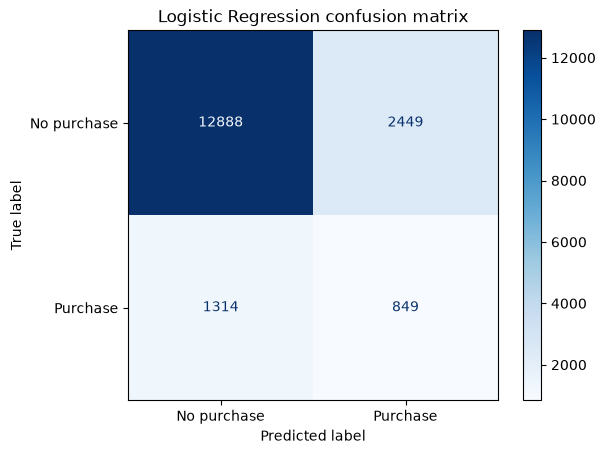

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test, prediction, display_labels=["No purchase", "Purchase"], cmap="Blues"
)
plt.title("Logistic Regression confusion matrix")
plt.show()


## 7. 模型學到哪些線索？

正係數表示特徵增加時購買傾向通常上升，負係數則通常下降。這代表**關聯，不是因果**。


In [9]:
coefficients = pd.DataFrame({
    "特徵": feature_names,
    "係數": model.named_steps["classifier"].coef_[0],
}).sort_values("係數", ascending=False)
display(coefficients.style.format({"係數": "{:+.3f}"}))


,特徵,係數
1,add_to_cart,+0.466
2,session_hour,+0.092
0,page_view,+0.016
3,is_weekend,-0.014


## 8. 預測新的工作階段

新資料必須使用與訓練時相同的欄位名稱與意義。


In [10]:
new_sessions = pd.DataFrame([
    {"page_view": 1, "add_to_cart": 0, "session_hour": 10, "is_weekend": 0},
    {"page_view": 5, "add_to_cart": 1, "session_hour": 20, "is_weekend": 1},
])
new_probability = model.predict_proba(new_sessions)[:, 1]
new_prediction = model.predict(new_sessions)
new_sessions["購買機率"] = new_probability
new_sessions["預測類別"] = new_prediction
display(new_sessions.style.format({"購買機率": "{:.1%}"}))


,page_view,add_to_cart,session_hour,is_weekend,購買機率,預測類別
0,1,0,10,0,41.3%,0
1,5,1,20,1,72.9%,1


## 9. 動手練習：降低分類門檻

行銷團隊不想漏掉潛在買家，決定把門檻從 0.50 降為 0.45。請先預測：被預測為購買的人數與購買類別的 recall 會如何改變？再執行下方答案。


In [11]:
# 參考答案：可先遮住，再自行完成。
threshold = 0.45
prediction_at_045 = (purchase_probability >= threshold).astype(int)
print(f"門檻 0.50，預測購買人數：{prediction.sum():,}")
print(f"門檻 0.45，預測購買人數：{prediction_at_045.sum():,}")
print(classification_report(y_test, prediction_at_045, target_names=["未購買", "購買"], digits=3, zero_division=0))


門檻 0.50，預測購買人數：3,298
門檻 0.45，預測購買人數：5,263
              precision    recall  f1-score   support

         未購買      0.909     0.725     0.807     15337
          購買      0.199     0.485     0.282      2163

    accuracy                          0.695     17500
   macro avg      0.554     0.605     0.544     17500
weighted avg      0.821     0.695     0.742     17500



### 練習解讀

降低門檻後，預測購買人數與 recall 通常上升；代價是誤判也可能增加，使 precision 下降。門檻應依行銷成本與漏掉顧客的損失決定。

## 常見錯誤與重點整理

- 不可把答案 `purchase` 放入特徵。
- 不要反覆用測試集調整模型。
- 類別不平衡時不可只看 accuracy。
- 機率是估計，不是保證；係數是關聯，不是因果。
- Logistic Regression 先估計機率，再用門檻完成分類。
- 下一步可加入客群、裝置等類別特徵，學習 One-Hot Encoding。
